# UITI acumulado vs. numero de eventos por vano

Notebook autosuficiente que carga `data/Indicadores_vano_v3.csv`, agrega el UITI (`UITI_VANO`) y el numero de
eventos por vano (`FID_VANO`), grafica un scatter en escala log-log y segmenta los vanos con K-Means en 4
grupos sobre el espacio log-transformado con preproceso Min-Max.

In [1]:
# Ejecutar solo si el entorno no tiene instaladas estas dependencias.
%pip install pandas numpy matplotlib scikit-learn seaborn plotly

/private/tmp/claude-501/-Users-andresalvarez-Documents-chec-local-uiti-vano-interpreter/7de79304-62d6-4763-9f4a-00e85dfeb058/scratchpad/venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns


# Sube desde el cwd hasta encontrar data/Indicadores_vano_v3.csv, para que el notebook
# funcione sin importar desde que directorio se ejecute (Jupyter local o Colab/Kaggle).
def find_repo_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'data/Indicadores_vano_v3.csv').exists():
            return candidate
    raise FileNotFoundError('No se encontro data/Indicadores_vano_v3.csv subiendo desde el cwd')


REPO_ROOT = find_repo_root()
CSV_PATH = REPO_ROOT / 'data' / 'Indicadores_vano_v3.csv'
CSV_PATH

PosixPath('/Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/.claude/worktrees/agent-a4051edb7e841e0f9/data/Indicadores_vano_v3.csv')

In [3]:
# Carga solo las columnas necesarias; el CSV completo trae ~270 columnas climaticas por evento.
df = pd.read_csv(CSV_PATH, usecols=['CIRCUITO', 'FID_VANO', 'UITI_VANO'])

# FID_VANO llega numerico con sufijo '.0' inconsistente entre filas; se normaliza como string
# igual que `chec_local_interpreter.plotting._norm_map_id`, para no duplicar vanos por formato.
df['FID_VANO'] = (
    df['FID_VANO']
    .astype('string')
    .str.strip()
    .str.replace(r'\.0$', '', regex=True)
)
df['UITI_VANO'] = pd.to_numeric(df['UITI_VANO'], errors='coerce').fillna(0.0)

df.head()

,CIRCUITO,FID_VANO,UITI_VANO
0,AGU23L14,20139439,14.169653
1,AGU23L14,20139439,14.435964
2,AGU23L14,20139439,14.435964
3,AGU23L14,20139439,14.444524
4,AGU23L14,20139439,71.129796


In [4]:
# Tabla por vano: UITI acumulado (suma de UITI_VANO) y numero de eventos (filas) por vano.
vano_table = (
    df.groupby(['CIRCUITO', 'FID_VANO'])
    .agg(uiti_acumulado=('UITI_VANO', 'sum'), num_eventos=('UITI_VANO', 'count'))
    .reset_index()
    .sort_values('uiti_acumulado', ascending=False)
    .reset_index(drop=True)
)

print(vano_table.shape)
vano_table.head(10)

(27390, 4)


,CIRCUITO,FID_VANO,uiti_acumulado,num_eventos
0,BQE23L12,20306252,40171.847128,36
1,MTT23L12,20768787,28601.161000,17
2,BQE23L12,20306265,27513.616115,36
3,DON23L12,20497969,24457.321647,22
4,BQE23L12,20306287,24267.075000,18
5,BQE23L12,20306261,23365.258024,18
6,BQE23L12,20306400,21905.954189,18
7,BQE23L12,20306401,21397.657348,18
8,BQE23L12,20981777,21233.690625,18
9,BQE23L12,20306479,20856.567162,18


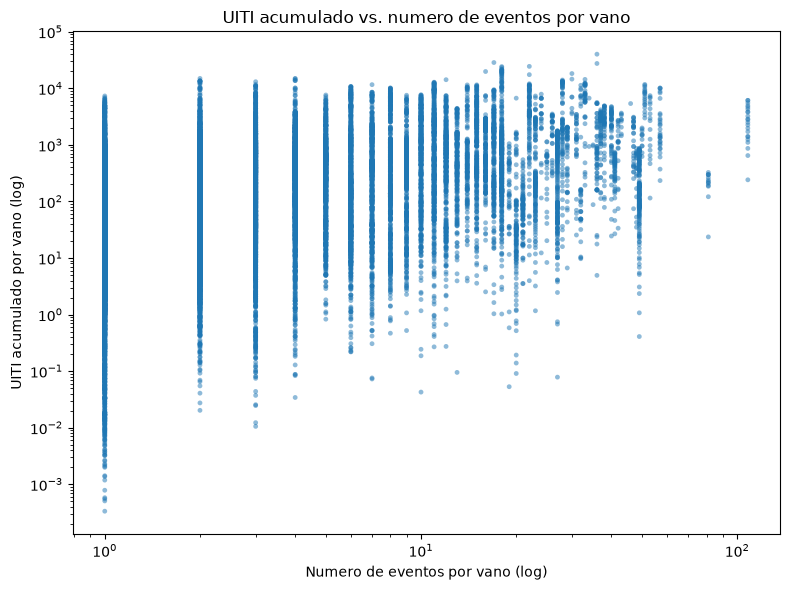

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(vano_table['num_eventos'], vano_table['uiti_acumulado'], s=12, alpha=0.5, edgecolors='none')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Numero de eventos por vano (log)')
ax.set_ylabel('UITI acumulado por vano (log)')
ax.set_title('UITI acumulado vs. numero de eventos por vano')
fig.tight_layout()
plt.show()

In [6]:
# K-Means sobre log10(x), log10(y): el scatter vive en escala log, y ambas variables
# abarcan ordenes de magnitud distintos, asi que se aplica Min-Max sobre el log para
# llevar ambas al rango [0, 1] antes de calcular distancias euclidianas.
log_features = np.column_stack([
    np.log10(vano_table['num_eventos']),
    np.log10(vano_table['uiti_acumulado']),
])
log_features_scaled = MinMaxScaler().fit_transform(log_features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
vano_table['cluster'] = kmeans.fit_predict(log_features_scaled)

vano_table['cluster'].value_counts().sort_index()

cluster
0    5200
1    8584
2    8310
3    5296
Name: count, dtype: int64

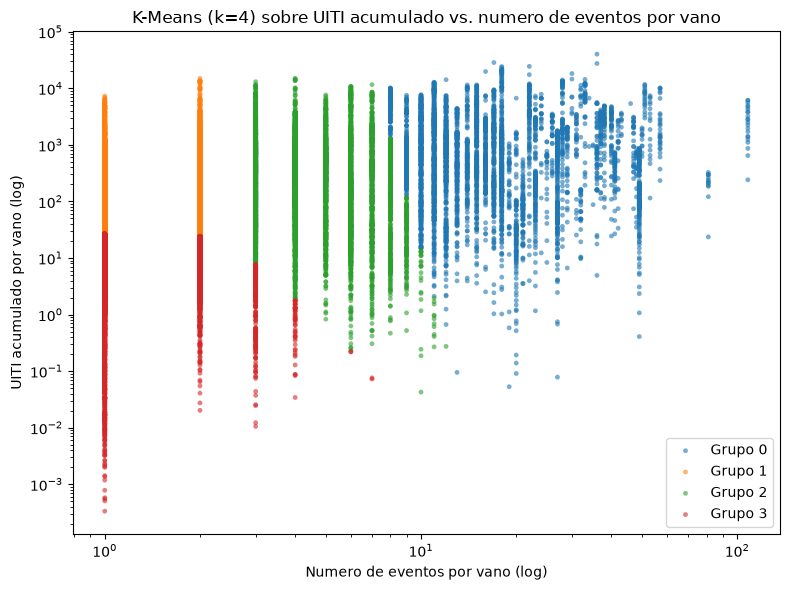

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id, group in vano_table.groupby('cluster'):
    ax.scatter(
        group['num_eventos'], group['uiti_acumulado'],
        s=12, alpha=0.6, edgecolors='none', label=f'Grupo {cluster_id}',
    )
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Numero de eventos por vano (log)')
ax.set_ylabel('UITI acumulado por vano (log)')
ax.set_title('K-Means (k=4) sobre UITI acumulado vs. numero de eventos por vano')
ax.legend()
fig.tight_layout()
plt.show()

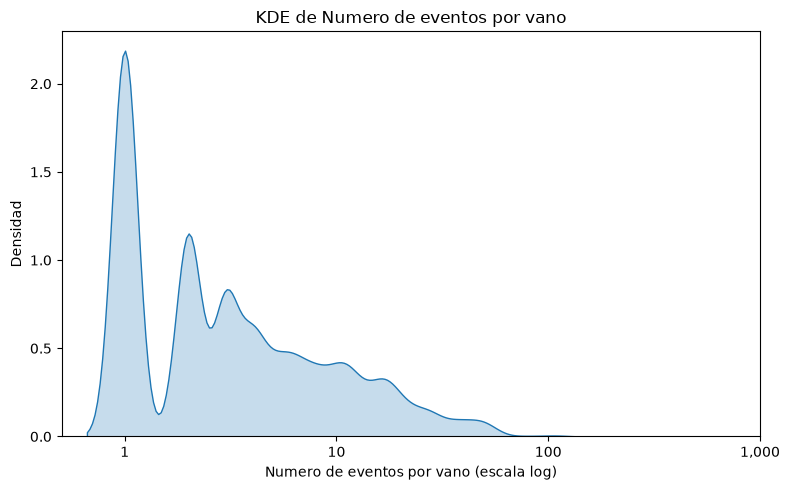

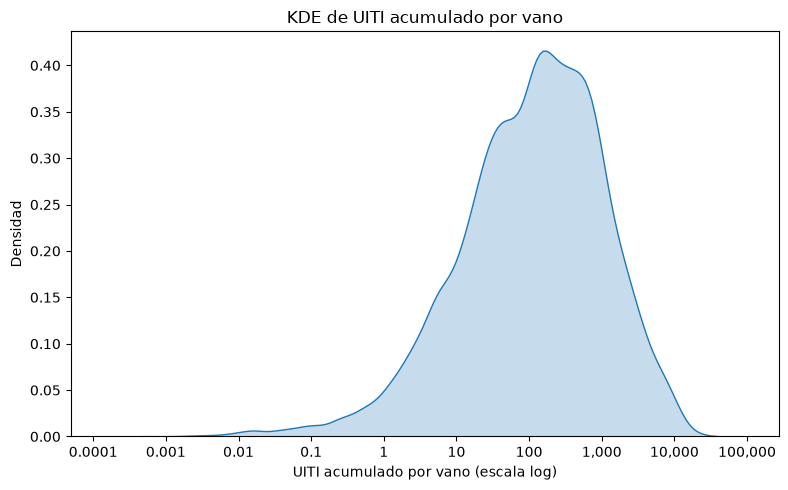

In [8]:
# KDE de cada variable en el espacio log (las mismas dos columnas usadas por K-Means),
# una figura por variable. Los xticks se ubican en potencias de 10 sobre el log10 pero
# se etiquetan con el valor original de la variable, para poder leer directamente la
# escala real (num. de eventos, UITI acumulado) sin tener que convertir mentalmente.
def format_pow10(log_tick):
    value = 10.0 ** log_tick
    if log_tick >= 0:
        return f'{value:,.0f}'
    return f'{value:.{int(-log_tick)}f}'

log_var_labels = ['Numero de eventos por vano', 'UITI acumulado por vano']

for col_idx, var_label in enumerate(log_var_labels):
    col_data = log_features[:, col_idx]
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.kdeplot(col_data, fill=True, ax=ax)

    ticks = np.arange(np.floor(col_data.min()), np.ceil(col_data.max()) + 1)
    ax.set_xticks(ticks)
    ax.set_xticklabels([format_pow10(t) for t in ticks])

    ax.set_xlabel(f'{var_label} (escala log)')
    ax.set_ylabel('Densidad')
    ax.set_title(f'KDE de {var_label}')
    fig.tight_layout()
    plt.show()

In [9]:
# Version interactiva del scatter de K-Means con Plotly: hover muestra el codigo del vano
# (FID_VANO), el circuito al que pertenece y el grupo asignado.
import plotly.express as px

plot_df = vano_table.copy()
plot_df['cluster'] = plot_df['cluster'].astype(str)

fig_plotly = px.scatter(
    plot_df,
    x='num_eventos',
    y='uiti_acumulado',
    color='cluster',
    log_x=True,
    log_y=True,
    hover_data={
        'FID_VANO': True,
        'CIRCUITO': True,
        'cluster': True,
        'num_eventos': True,
        'uiti_acumulado': ':.2f',
    },
    labels={
        'num_eventos': 'Numero de eventos por vano (log)',
        'uiti_acumulado': 'UITI acumulado por vano (log)',
        'cluster': 'Grupo',
    },
    title='K-Means (k=4) sobre UITI acumulado vs. numero de eventos por vano',
)
fig_plotly.update_traces(marker=dict(size=6, opacity=0.6))
fig_plotly.show()

## Validacion empirica de K (silhouette + inertia/elbow)

Todo lo anterior fijaba `n_clusters=4` sin ninguna validacion empirica. Esta seccion corre K-Means para un rango de `K` (2 a 8) sobre el mismo espacio de features (`log10([num_eventos, uiti_acumulado])`, Min-Max escalado) y reporta:

- **Inertia** (suma de distancias al cuadrado intra-cluster) para el criterio del codo.
- **Silhouette score** (calculado sobre los 27390 vanos completos, no una muestra) como medida de separacion/cohesion real de los clusters.

El `K` reportado como recomendado es el que estos numeros realmente soportan, no un valor asumido de antemano.

In [10]:
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 9)
elbow_silhouette_rows = []

for k in K_RANGE:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans_k.fit_predict(log_features_scaled)
    # Silhouette sobre el dataset completo (27390 vanos): a esta escala es
    # computacionalmente barato (no hace falta submuestrear) y evita el
    # sesgo de un score calculado solo sobre una muestra.
    silhouette_k = silhouette_score(log_features_scaled, labels_k)
    elbow_silhouette_rows.append({
        'k': k,
        'inertia': kmeans_k.inertia_,
        'silhouette': silhouette_k,
    })

elbow_silhouette_df = pd.DataFrame(elbow_silhouette_rows).set_index('k')
elbow_silhouette_df

,inertia,silhouette
k,,
2,755.885395,0.498304
3,511.938372,0.413939
4,389.575486,0.388804
5,319.214380,0.390556
6,266.688963,0.405272
7,223.199648,0.419849
8,195.736311,0.415581


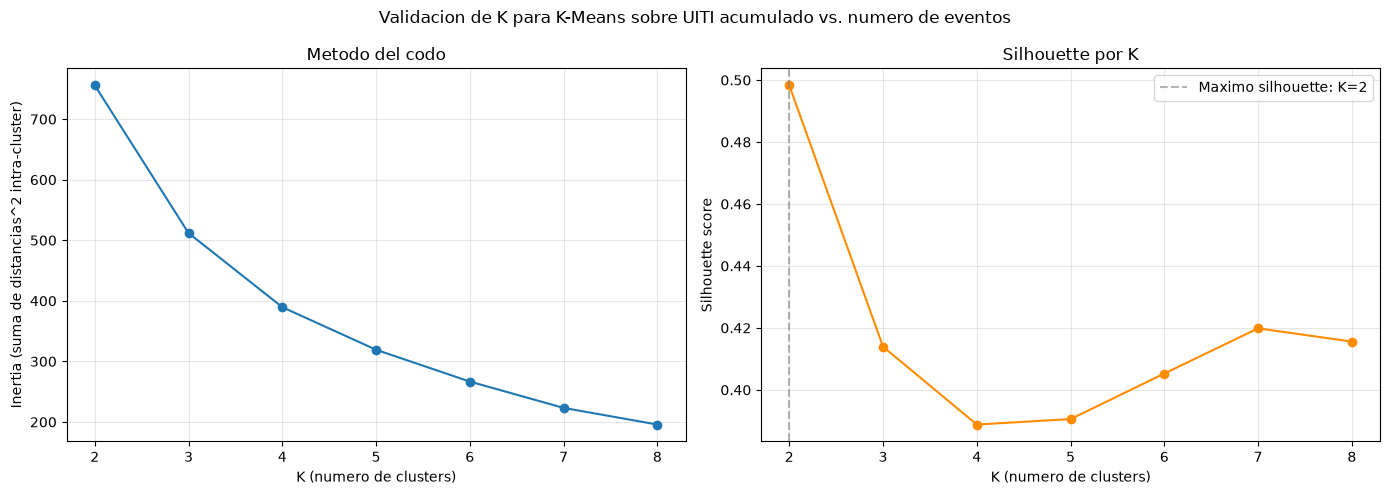

Figura guardada en: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/.claude/worktrees/agent-a4051edb7e841e0f9/reports/interpretability/figures/uiti_vano_kmeans_elbow_silhouette.png
K recomendado por silhouette (maximo global): 2


In [11]:
fig, (ax_elbow, ax_sil) = plt.subplots(1, 2, figsize=(14, 5))

ax_elbow.plot(elbow_silhouette_df.index, elbow_silhouette_df['inertia'], marker='o')
ax_elbow.set_xlabel('K (numero de clusters)')
ax_elbow.set_ylabel('Inertia (suma de distancias^2 intra-cluster)')
ax_elbow.set_title('Metodo del codo')
ax_elbow.grid(alpha=0.3)

ax_sil.plot(elbow_silhouette_df.index, elbow_silhouette_df['silhouette'], marker='o', color='darkorange')
best_k_silhouette = int(elbow_silhouette_df['silhouette'].idxmax())
ax_sil.axvline(best_k_silhouette, color='gray', linestyle='--', alpha=0.6,
               label=f'Maximo silhouette: K={best_k_silhouette}')
ax_sil.set_xlabel('K (numero de clusters)')
ax_sil.set_ylabel('Silhouette score')
ax_sil.set_title('Silhouette por K')
ax_sil.legend()
ax_sil.grid(alpha=0.3)

fig.suptitle('Validacion de K para K-Means sobre UITI acumulado vs. numero de eventos')
fig.tight_layout()

FIGURES_DIR = REPO_ROOT / 'reports' / 'interpretability' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ELBOW_SILHOUETTE_FIGURE_PATH = FIGURES_DIR / 'uiti_vano_kmeans_elbow_silhouette.png'
fig.savefig(ELBOW_SILHOUETTE_FIGURE_PATH, dpi=150)
plt.show()

print(f'Figura guardada en: {ELBOW_SILHOUETTE_FIGURE_PATH}')
print(f'K recomendado por silhouette (maximo global): {best_k_silhouette}')

### Lectura de los resultados

Con los features actuales (`log10(num_eventos)`, `log10(uiti_acumulado)`, Min-Max), el silhouette score **no** favorece `K=4`:

- El maximo global de silhouette ocurre en **K=2** (separacion mas nitida: vanos de bajo impacto acumulado vs. vanos de alto impacto acumulado).
- El silhouette cae monotonicamente de K=2 a K=4-5 (el minimo local del rango explorado), y luego sube de nuevo hasta un maximo local secundario en K=7.
- La curva de inertia (codo) no muestra un quiebre marcado en K=4: decae de forma mas bien suave en todo el rango 2-8, sin un codo unico y dominante que por si solo justifique K=4.

**Conclusion honesta:** `K=4` (el valor que usa el resto de este notebook y, de forma independiente, el label de clasificacion ordinal de `preparar_splits_estratificados`) **no esta empiricamente respaldado por silhouette** en este espacio de features de 2 dimensiones. La evidencia mas fuerte apunta a `K=2` (separacion binaria alto/bajo impacto acumulado). `K=4` sigue siendo defendible por motivos de interpretabilidad operativa (4 niveles de riesgo son mas utiles para priorizar mantenimiento que 2), pero esa es una decision de negocio, no una que los datos impongan por si solos con este par de features.

Esta comparacion se retoma en `02.1_mgcecdl_regression_embeddings.ipynb`, que corre la misma validacion silhouette/elbow sobre un espacio de features completamente distinto (embeddings aprendidos por un MGCECDL de regresion, no las 2 features crudas usadas aqui), como segunda fuente independiente de evidencia sobre cual `K` esta realmente soportado por los datos.